In [1]:
import numpy as np
from astropy.io import fits

In [2]:
import matplotlib.pyplot as plt

In [3]:
from astropy.io import fits

def getarray(fitsfile):
    # Load the first FITS file
    hdul1 = fits.open(fitsfile)

    x = []
    for i in range(80):
        x.append(hdul1[1].data[i][6])
    y = np.array(x)
    
    return(y)

In [4]:
#TEST WITH COSMO2 COSMOLOGY
theory_prev = getarray("../data/dv/test-emu-outlier-cosmo/sim_map3_model_cosmo2.fits")
theory =  getarray("../data/dv/test-emu-outlier-cosmo/sim_map3_model_cosmo2_change_fastnc_scheme2.fits")
emulator = getarray("../data/dv/test-emu-outlier-cosmo/sim_map3_emu_cosmo2.fits")
los_after = getarray("../data/dv/test-emu-outlier-cosmo/sim_map3_los_after_cosmo2.fits")
los_after_morez = getarray("../data/dv/test-emu-outlier-cosmo/sim_map3_emu_cosmo2_finez.fits")
print(emulator-los_after)
theory_sections = np.split(theory,20)
emulator_sections = np.split(emulator,20)
los_after_sections = np.split(los_after, 20)
los_after_sections_morez = np.split(los_after_morez, 20)

[-4.21539954e-14 -5.41199967e-15  1.05866198e-16  5.99755565e-17
 -6.93694387e-14 -6.62743764e-15  6.01319002e-16  1.48052790e-16
 -7.77360236e-14 -6.96223051e-15  7.51350506e-16  1.75114548e-16
 -7.91151981e-14 -6.95670274e-15  7.85308670e-16  1.80817588e-16
 -1.20749937e-13 -7.80626604e-15  1.64826388e-15  3.18799148e-16
 -1.37366993e-13 -7.98323883e-15  2.01563982e-15  3.74181758e-16
 -1.40445838e-13 -7.90187531e-15  2.10268273e-15  3.86490916e-16
 -1.57646644e-13 -7.65208542e-15  2.62849452e-15  4.54500780e-16
 -1.61660721e-13 -7.34060263e-15  2.79914037e-15  4.74618653e-16
 -1.65251042e-13 -6.94147033e-15  2.99579274e-15  4.98765547e-16
 -2.35512861e-13 -1.17329279e-14  2.24537405e-15  3.33600386e-16
 -2.78033230e-13 -1.49147986e-14  1.53963173e-15  1.81428464e-16
 -2.86883076e-13 -1.55880561e-14  1.33280744e-15  1.38740827e-16
 -3.31691703e-13 -2.19945410e-14 -6.92403144e-16 -1.99467336e-16
 -3.43137404e-13 -2.37417137e-14 -1.33077002e-15 -3.04832120e-16
 -3.54806583e-13 -2.58454

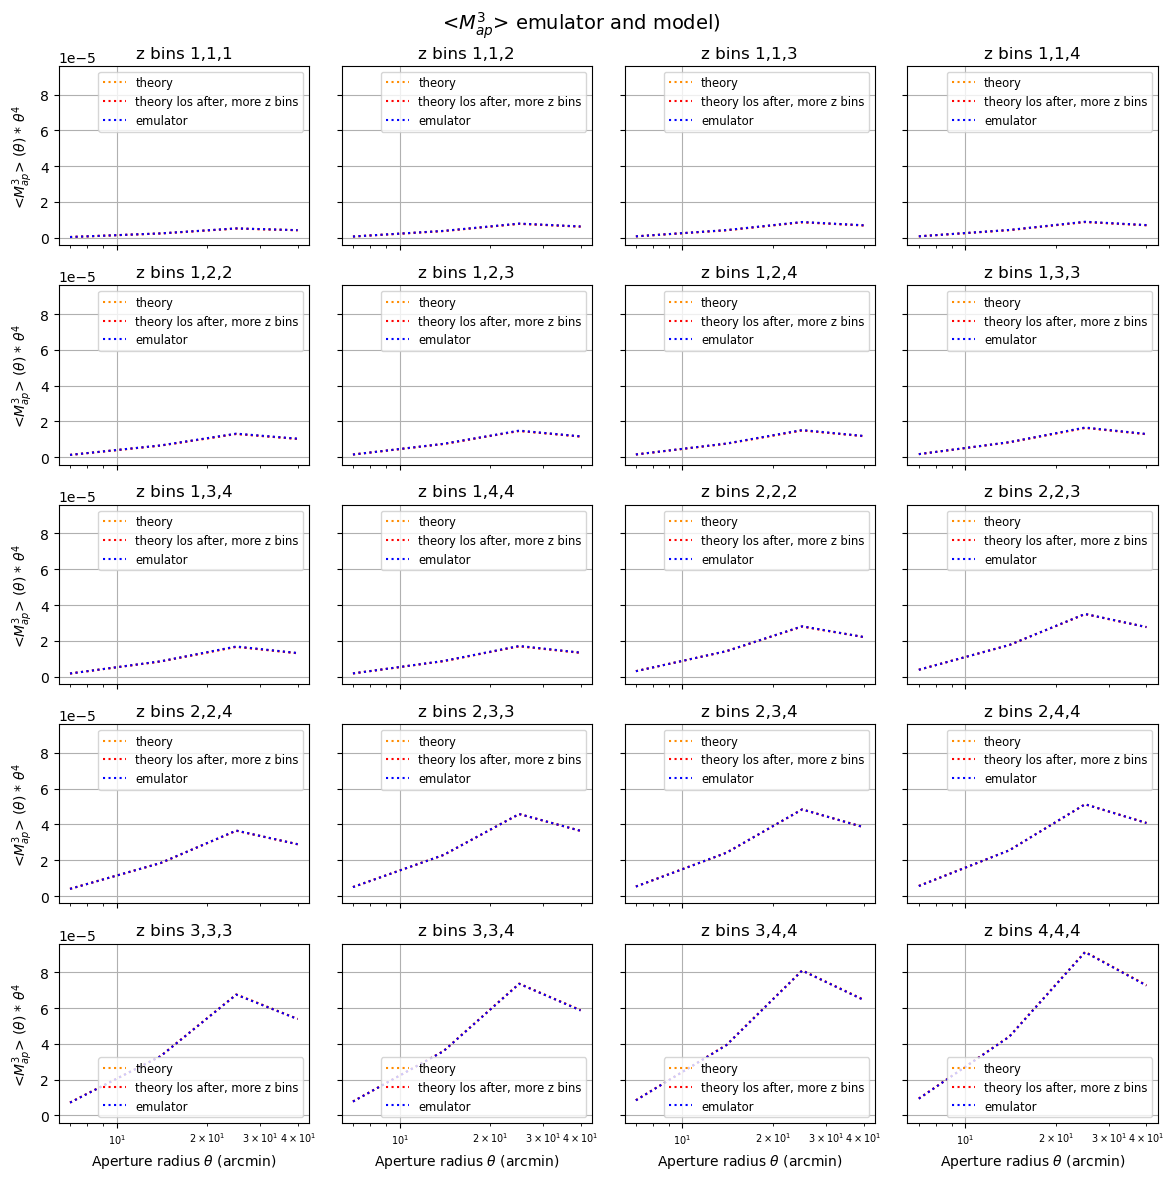

In [5]:
indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    ax.plot(x_values, theory_sections[i]*x_values**4, color='darkorange', ls=':',label='theory')
    ax.plot(x_values, los_after_sections_morez[i]*x_values**4, color='r', ls=':',label='theory los after, more z bins')
    ax.plot(x_values, emulator_sections[i]*x_values**4, color='b', ls=':',label='emulator')
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"<$M_{ap}^3$> ($\theta$) * $\theta^4$")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> emulator and model)", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
#plt.savefig("Map3_theo_measurement_20May24.pdf")
plt.show()

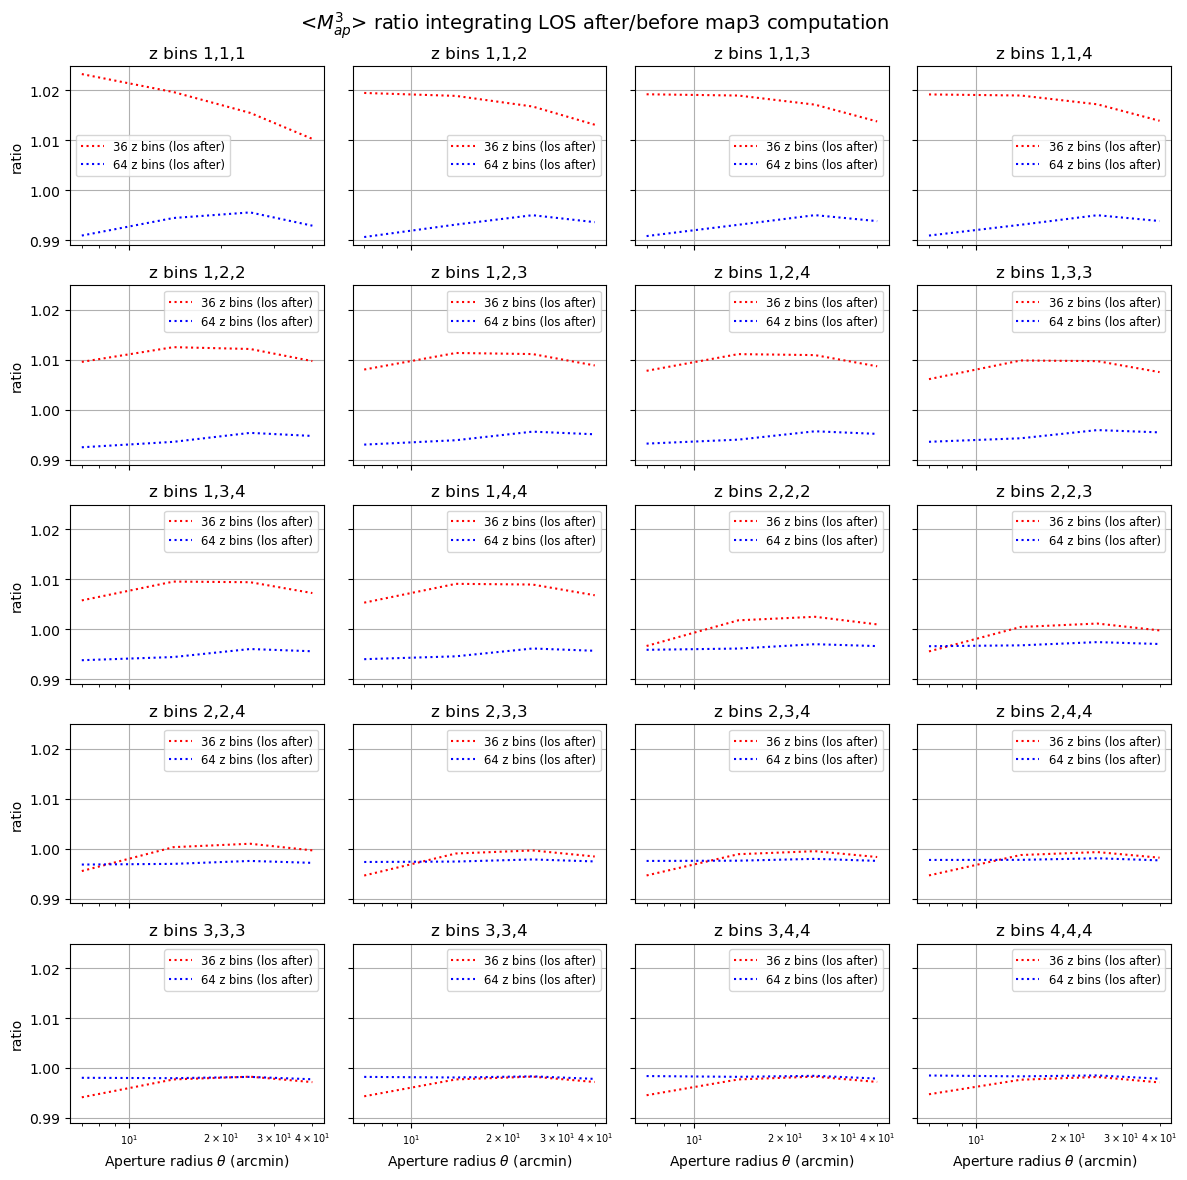

In [6]:
indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    ax.plot(x_values, los_after_sections[i]/theory_sections[i], color='r', ls=':',label='36 z bins (los after)')
    ax.plot(x_values, los_after_sections_morez[i]/theory_sections[i], color='b', ls=':',label='64 z bins (los after)')
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel("ratio")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> ratio integrating LOS after/before map3 computation", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
#plt.savefig("LOS_integration_test.pdf")
plt.show()

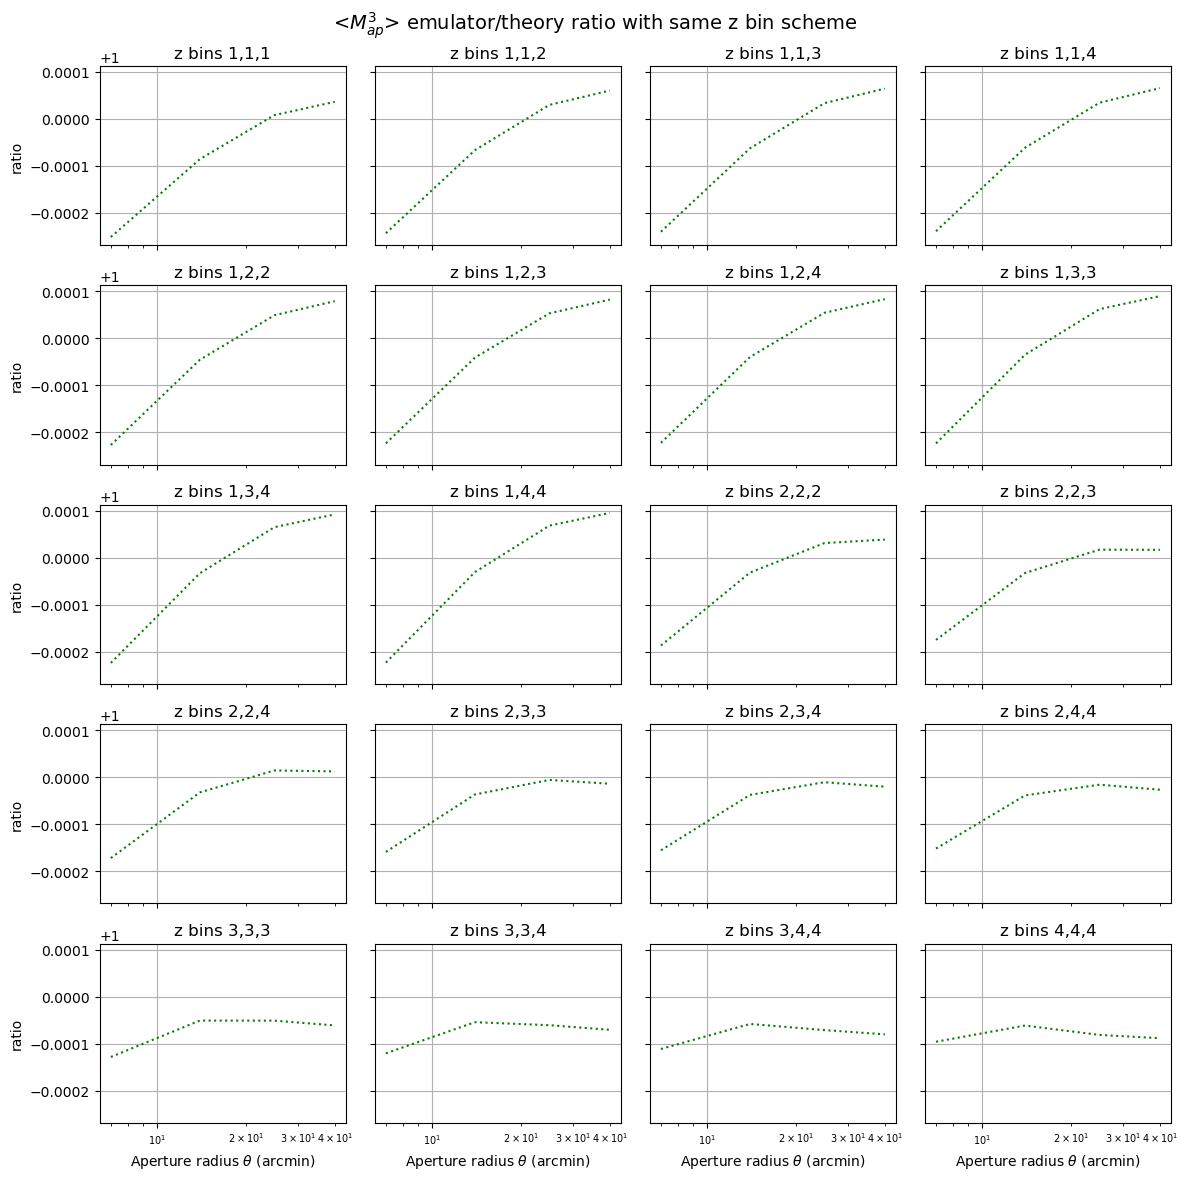

In [7]:
indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    ax.plot(x_values, emulator_sections[i]/los_after_sections[i], color='g', ls=':')
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel("ratio")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    #ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> emulator/theory ratio with same z bin scheme", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
#plt.savefig("emulator_vs_theory_ratio_with_same_zbin_scheme.pdf")
plt.show()

In [8]:
np.logspace(np.log10(0.005), np.log10(0.15),6)

array([0.005     , 0.00987175, 0.0194903 , 0.03848068, 0.07597435,
       0.15      ])

In [9]:
np.logspace(-4, np.log10(0.1),30)

array([0.0001    , 0.0001269 , 0.00016103, 0.00020434, 0.00025929,
       0.00032903, 0.00041753, 0.00052983, 0.00067234, 0.00085317,
       0.00108264, 0.00137382, 0.00174333, 0.00221222, 0.00280722,
       0.00356225, 0.00452035, 0.00573615, 0.00727895, 0.00923671,
       0.01172102, 0.01487352, 0.01887392, 0.02395027, 0.03039195,
       0.0385662 , 0.04893901, 0.06210169, 0.07880463, 0.1       ])

In [10]:
np.linspace(0.15,3,100)

array([0.15      , 0.17878788, 0.20757576, 0.23636364, 0.26515152,
       0.29393939, 0.32272727, 0.35151515, 0.38030303, 0.40909091,
       0.43787879, 0.46666667, 0.49545455, 0.52424242, 0.5530303 ,
       0.58181818, 0.61060606, 0.63939394, 0.66818182, 0.6969697 ,
       0.72575758, 0.75454545, 0.78333333, 0.81212121, 0.84090909,
       0.86969697, 0.89848485, 0.92727273, 0.95606061, 0.98484848,
       1.01363636, 1.04242424, 1.07121212, 1.1       , 1.12878788,
       1.15757576, 1.18636364, 1.21515152, 1.24393939, 1.27272727,
       1.30151515, 1.33030303, 1.35909091, 1.38787879, 1.41666667,
       1.44545455, 1.47424242, 1.5030303 , 1.53181818, 1.56060606,
       1.58939394, 1.61818182, 1.6469697 , 1.67575758, 1.70454545,
       1.73333333, 1.76212121, 1.79090909, 1.81969697, 1.84848485,
       1.87727273, 1.90606061, 1.93484848, 1.96363636, 1.99242424,
       2.02121212, 2.05      , 2.07878788, 2.10757576, 2.13636364,
       2.16515152, 2.19393939, 2.22272727, 2.25151515, 2.28030